# Численное моделирование распространения сейсмических волн в двумерной среде MILEN SEM 2D. Часть первая.

## Глава VII: Эйлерова декартова сетка материала

### Научная задача

В предыдущей главе мы создали материал, следующий криволинейной геометрии слоев. Однако такой подход имеет ограничения при передаче данных коллегам-геофизикам, использующим метод конечных разностей.

В этой главе мы реализуем альтернативный подход: поверх криволинейной слоистой геометрии натягиваем абсолютно ровную декартову сетку материала. 

1. Такой подход редко используется в МСЭ, хотя и возможен
2. Позволит отладить методы интерполяции материалов
3. Обеспечит совместимость с методом конечных разностей

### Задача 1: Подготовка сетки материала

Создаем декартову сетку дискретизации 5x5. Это соответствует размеру ячейки для метода конечных разностей, достаточному, что бы улавливать медленные (~ 500 м/с) с частотой 30 Hz. Данная сетка будет передана геофизикам. Для нужд метода конечных элементов в fc будет записана угрубленная версия той же сетки с дискретностью 25x5, поскольку упругие свойства материала слабо меняются по X, и такая запись позволит существенно уменьшить размеры модели.



In [53]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fc_model import FCModel
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator, RBFInterpolator

# Глобальный флаг для управления отображением графиков
SHOW_PLOTS = True  # True - показывать графики, False - только сохранять

#### 1. Загрузка данных ####

In [54]:
# Загрузка геометрии слоев
layer_data_path = Path('data/dev_1_5_2_layer_boundaries_quadratic.npz')
layer_data = np.load(layer_data_path)

layer_boundaries_array = layer_data['layer_boundaries_array']  # shape (75, 1176)
formations = layer_data['formations']
distances = layer_data['distances']  # shape (1176,)
well1_depths = layer_data['well1_depths']
well2_depths = layer_data['well2_depths']

print(f"Загружена геометрия слоев: {layer_boundaries_array.shape}, {distances.shape}")
print(f"Количество формаций: {len(formations)}")

Загружена геометрия слоев: (75, 1176), (1176,)
Количество формаций: 75


Добавляем поверхность (глубина 0) в начало

In [55]:
all_boundaries = np.vstack([np.zeros((1, distances.shape[0])), layer_boundaries_array])

In [56]:
# Границы модели
x_min, x_max = distances[0], distances[-1]
y_min = 0
y_max = np.max(layer_boundaries_array)

print(f"\nГраницы модели:")
print(f"X: от {x_min:.1f} до {x_max:.1f} м")
print(f"Y: от {y_min:.1f} до {y_max:.1f} м")


Границы модели:
X: от 0.0 до 11750.0 м
Y: от 0.0 до 2750.0 м


In [57]:
# Загрузка материала
material_data_path = Path('data/dev_1_6_model_material_new.npz')
material_data = np.load(material_data_path, allow_pickle=True)
lagrange_coords = material_data['coords']  # координаты узлов материала
lagrange_props = material_data['properties']  # свойства [E, nu, rho]

In [58]:
material_data['properties']

array([[[2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        [2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        [2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        ...,
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03],
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03],
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03]],

       [[2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        [2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        [2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        ...,
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03],
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03],
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03]],

       [[2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        [2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        [2.21560716e+09, 2.83925660e-01, 1.82377821e+03],
        ...,
        [5.23270938e+10, 2.83342323e-01, 2.55268747e+03],
        [5.23270938e+10, 2.83

In [59]:
def find_layer_at_point(x, y, distances, all_boundaries):
    """
    Определяет номер слоя (0-74) для точки (x, y).
    
    Args:
        x: горизонтальная координата
        y: глубина
        distances: массив горизонтальных координат профиля
        all_boundaries: массив границ слоев (76 границ для 75 слоев)
        
    Returns:
        layer_index: номер слоя (0-74) или -1 если вне модели
    """
    # Находим ближайший индекс по x
    x_idx = np.argmin(np.abs(distances - x))
    
    # Проверяем, в каком слое находится точка
    for layer_idx in range(len(all_boundaries) - 1):
        y_top = all_boundaries[layer_idx, x_idx]
        y_bottom = all_boundaries[layer_idx + 1, x_idx]
        
        if y_top <= y <= y_bottom:
            return layer_idx
    
    return -1  # Вне модели



In [60]:
# Задаем дискретизацию
dx, dy = 5, 5

# Строим декартову сетку
layer_grids = []

x_cells = np.arange(x_min+dx/2, x_max, dx)
y_cells = np.arange(y_min+dy/2, y_max, dy)

# Создаем сетку точек для интерполяции
# Создаем общий массив координат по X, Y для всех узлов сетки
X_grid, Y_grid = np.meshgrid(x_cells, y_cells, indexing='ij')
coords_grid = np.stack([X_grid, Y_grid], axis=-1)  # shape (N, 2), с координатами (x, y) каждой точки сетки


In [61]:
layer_indexes_grid = np.full(coords_grid.shape[:2], -1)

for i in range(coords_grid.shape[0]):
    for j in range(coords_grid.shape[1]):
        x = coords_grid[i,j][0]
        y = coords_grid[i,j][1]

        # Находим ближайший индекс по x
        x_idx = np.argmin(np.abs(distances - x))

        boundaries = all_boundaries[:-1, x_idx]

        layer_indexes_grid[i,j] = np.argmin(np.abs(boundaries - y))
        layer_indexes_grid[i, j] = np.where(boundaries < y)[0].max()


In [62]:
first_row_coords = lagrange_coords[0]  # shape (386, 2)
_, unic_index = np.unique(first_row_coords, axis=0, return_index=True)

In [63]:
def split_by_missing(input_data):
    diff = np.diff(input_data)
    break_pos = np.where(diff > 1)[0]  # индексы в input_data слева от разрыва
    missing = input_data[break_pos] + 1

    starts = np.r_[0, break_pos + 1]
    ends   = np.r_[break_pos + 1, len(input_data)]
    layers = [input_data[s:e] for s, e in zip(starts, ends)]

    output = []
    for i, layer in enumerate(layers):
        extended = []

        if i > 0:
            prev_last = layers[i-1][-1:-1]
            # prev_last = layers[i-1][-2]
            missing_before = missing[i-1]  # один пропуск на каждый разрыв

            extended.extend(prev_last)
            extended.append(missing_before)

        extended.extend(layer.tolist())

        if i < len(layers) - 1:
            next_first = layers[i+1][0:0]
            # next2_first = layers[i+1][1]

            extended.extend(next_first)

        output.append(extended)
    return output

layer_borders = split_by_missing(unic_index)

# # Проверка
# for row in layer_borders:
#     print(row)


#### 2. Построение интерполяторов для каждого слоя ####

Строитм интерполяторы для каждого слоя на основе исходного материала.


In [64]:
n_layers = len(formations)
layer_interpolators = []

print("\nПостроение интерполяторов для слоев:")

for layer_idx in range(n_layers):
    print(f"  Слой {layer_idx+1}/{n_layers}: {formations[layer_idx]}", end='')
    
    layer_points = lagrange_coords[:, layer_borders[layer_idx]].reshape(-1, 2)  # координаты узлов материала
    layer_props = lagrange_props[:, layer_borders[layer_idx]].reshape(-1, 3)


    interp_E = CloughTocher2DInterpolator(layer_points, layer_props[:, 0], fill_value=np.mean(layer_props[:, 0]))
    interp_nu = CloughTocher2DInterpolator(layer_points, layer_props[:, 1], fill_value=np.mean(layer_props[:, 1]))
    interp_rho = CloughTocher2DInterpolator(layer_points, layer_props[:, 2], fill_value=np.mean(layer_props[:, 2]))

    
    layer_interpolators.append({
        'formation': formations[layer_idx],
        'n_points': len(layer_points),
        'interp_E': interp_E,
        'interp_nu': interp_nu,
        'interp_rho': interp_rho
    })
    
    print(f" - {len(layer_points)} точек")



Построение интерполяторов для слоев:
  Слой 1/75: песчаник - 3528 точек
  Слой 2/75: песчаник - 4704 точек
  Слой 3/75: песчаник - 5880 точек
  Слой 4/75: песчаник - 5880 точек
  Слой 5/75: песчаник - 4704 точек
  Слой 6/75: песчаник - 4704 точек
  Слой 7/75: песчаник - 4704 точек
  Слой 8/75: песчаник - 4704 точек
  Слой 9/75: песчаник - 5880 точек
  Слой 10/75: глина - 5880 точек
  Слой 11/75: глина - 3528 точек
  Слой 12/75: глина - 5880 точек
  Слой 13/75: глина - 4704 точек
  Слой 14/75: песчаник - 9408 точек
  Слой 15/75: песчаник - 4704 точек
  Слой 16/75: песчаник - 3528 точек
  Слой 17/75: песчаник - 3528 точек
  Слой 18/75: песчаник - 4704 точек
  Слой 19/75: песчаник - 4704 точек
  Слой 20/75: алевролит - 4704 точек
  Слой 21/75: алевролит - 5880 точек
  Слой 22/75: алевролит - 5880 точек
  Слой 23/75: алевролит - 4704 точек
  Слой 24/75: песчаник - 3528 точек
  Слой 25/75: песчаник - 19992 точек
  Слой 26/75: песчаник - 5880 точек
  Слой 27/75: песчаник - 7056 точек
  Слой

#### 3. Построение декартовой сетки ####

In [65]:
material_grid = np.zeros((*layer_indexes_grid.shape,3))

In [66]:
print(f"\nПостроение декартовых сеток для слоев (дискретизация {dx}×{dy} м):")

for layer_idx, interp_data in enumerate(layer_interpolators):
    formation = interp_data['formation']
    n_points = interp_data['n_points']
    interp_E = interp_data['interp_E']
    interp_nu = interp_data['interp_nu']
    interp_rho = interp_data['interp_rho']

    coords_in_layer = np.argwhere(layer_indexes_grid == layer_idx)

    layer_coords = coords_grid[coords_in_layer[:, 0], coords_in_layer[:, 1]]
    layer_coords_grid = layer_coords.reshape(-1, 2)

    # Пакетная интерполяция всех свойств
    E_values = interp_E(layer_coords_grid)
    nu_values = interp_nu(layer_coords_grid)
    rho_values = interp_rho(layer_coords_grid)
    
    material_grid[coords_in_layer[:, 0], coords_in_layer[:, 1], 0] = E_values
    material_grid[coords_in_layer[:, 0], coords_in_layer[:, 1], 1] = nu_values
    material_grid[coords_in_layer[:, 0], coords_in_layer[:, 1], 2] = rho_values

    print(f'Слой {layer_idx+1} реинтреполирован', np.min(rho_values), np.max(rho_values),)




Построение декартовых сеток для слоев (дискретизация 5×5 м):
Слой 1 реинтреполирован 1823.7239733864965 2056.497304416385
Слой 2 реинтреполирован 1823.7286874447882 2049.858380921823
Слой 3 реинтреполирован 1813.8707600276014 2023.9636469856712
Слой 4 реинтреполирован 1816.9991160673906 1991.9902963762559
Слой 5 реинтреполирован 1852.2020495816078 1967.6882909517317
Слой 6 реинтреполирован 1939.6993749300054 1999.5124270569954
Слой 7 реинтреполирован 1914.7119580120147 1996.2205923106824
Слой 8 реинтреполирован 1888.7607922423354 1952.1404135400091
Слой 9 реинтреполирован 1889.2010817813607 1966.0779976870274
Слой 10 реинтреполирован 1904.8664860555775 1993.3043425475657
Слой 11 реинтреполирован 1909.687442854806 1942.1501139888228
Слой 12 реинтреполирован 1905.0829076674918 1940.2598137504197
Слой 13 реинтреполирован 1890.1795014805905 1922.2250194286123
Слой 14 реинтреполирован 1862.3954058712704 1993.5703716472437
Слой 15 реинтреполирован 1892.0110155110503 1963.9116365883935
Слой 

#### 4. Визуализация сетки ####

In [67]:
""" Визуализация поля модуля Юнга (E_values) по всей расчетной декартовой сетке """

import matplotlib.pyplot as plt


def show_plot(title, field, cmap='viridis'):

    fig, ax = plt.subplots(figsize=(16,8))
    
    X, Y = np.meshgrid(coords_grid[:,0,0], coords_grid[0,:,1], indexing='ij')

    c = ax.pcolormesh(X, Y, field, cmap=cmap, shading='auto')
    plt.colorbar(c, ax=ax, label=title)

    ax.set_xlabel('x (м)')
    ax.set_ylabel('y (м)')
    ax.set_title(title)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)   # Инверсия оси Y (глубина вниз)
    plt.tight_layout()

    output_path = f'img/dev_1_7_{title}_layers.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"  Визуализация слоев: {output_path}")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()



  Визуализация слоев: img/dev_1_7_E_grid_layers.png


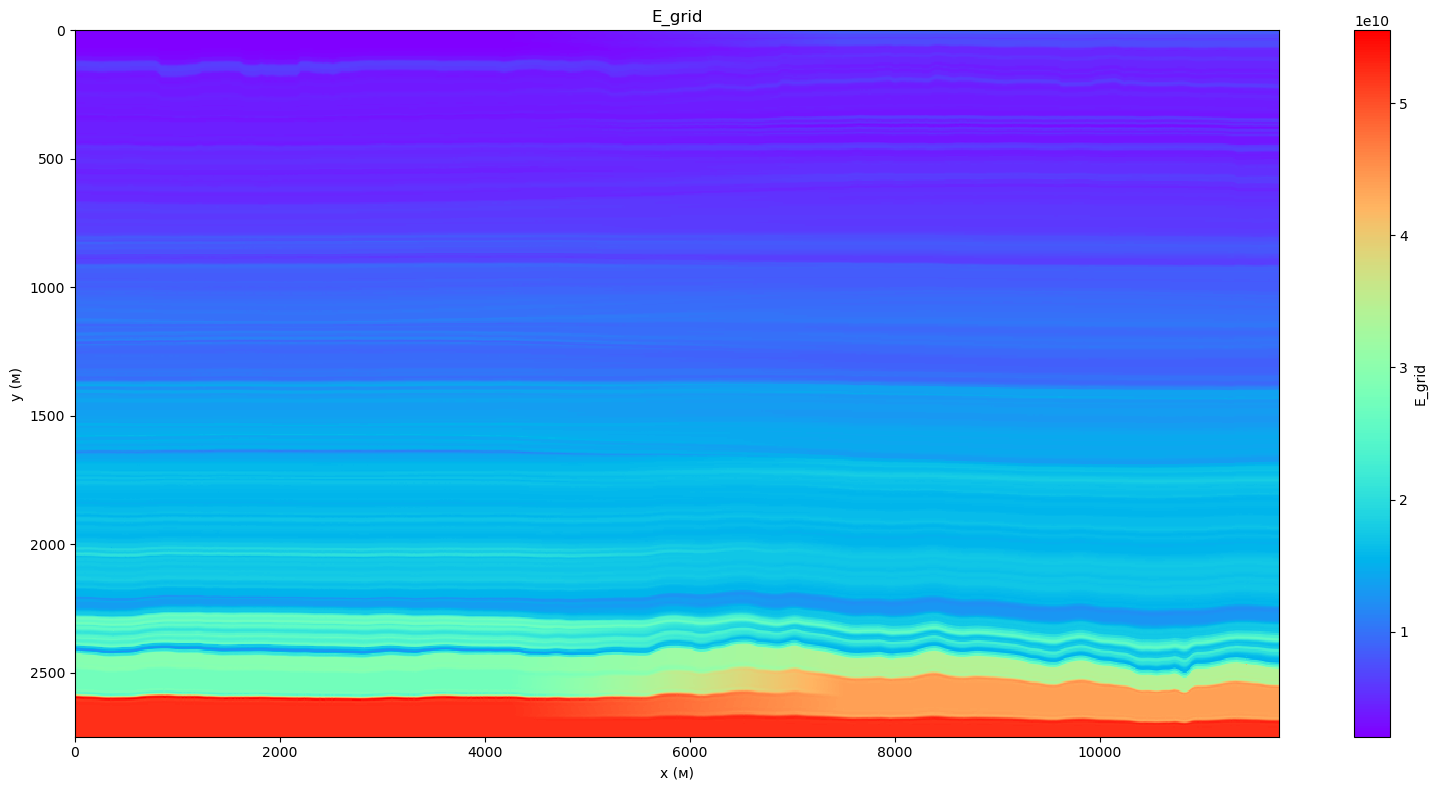

In [68]:
E_grid = material_grid[:, :, 0]  # Модуль Юнга для всех узлов
show_plot('E_grid', E_grid, 'rainbow')

  Визуализация слоев: img/dev_1_7_Layers_layers.png


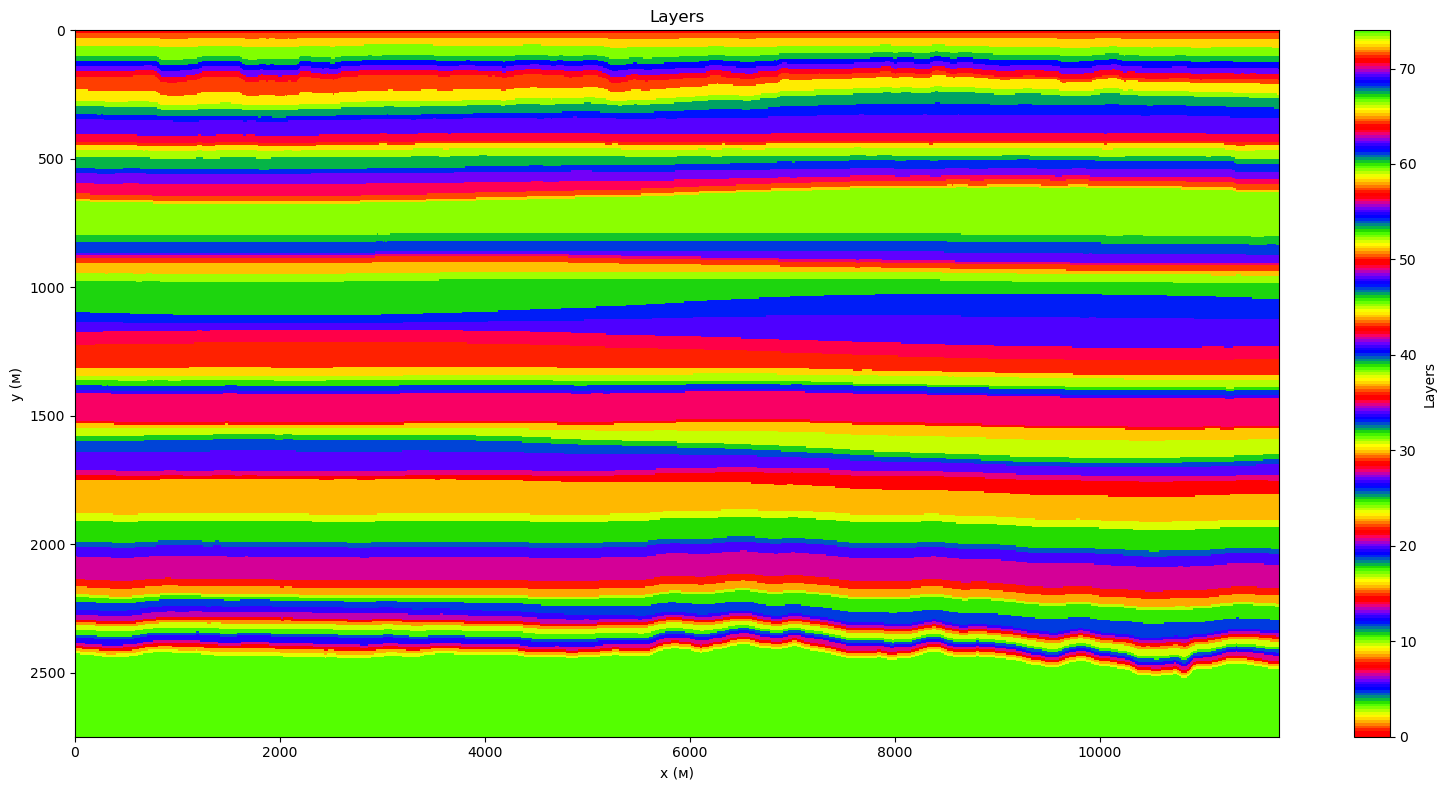

In [69]:
show_plot('Layers', layer_indexes_grid, 'prism')

  Визуализация слоев: img/dev_1_7_nu_values_layers.png


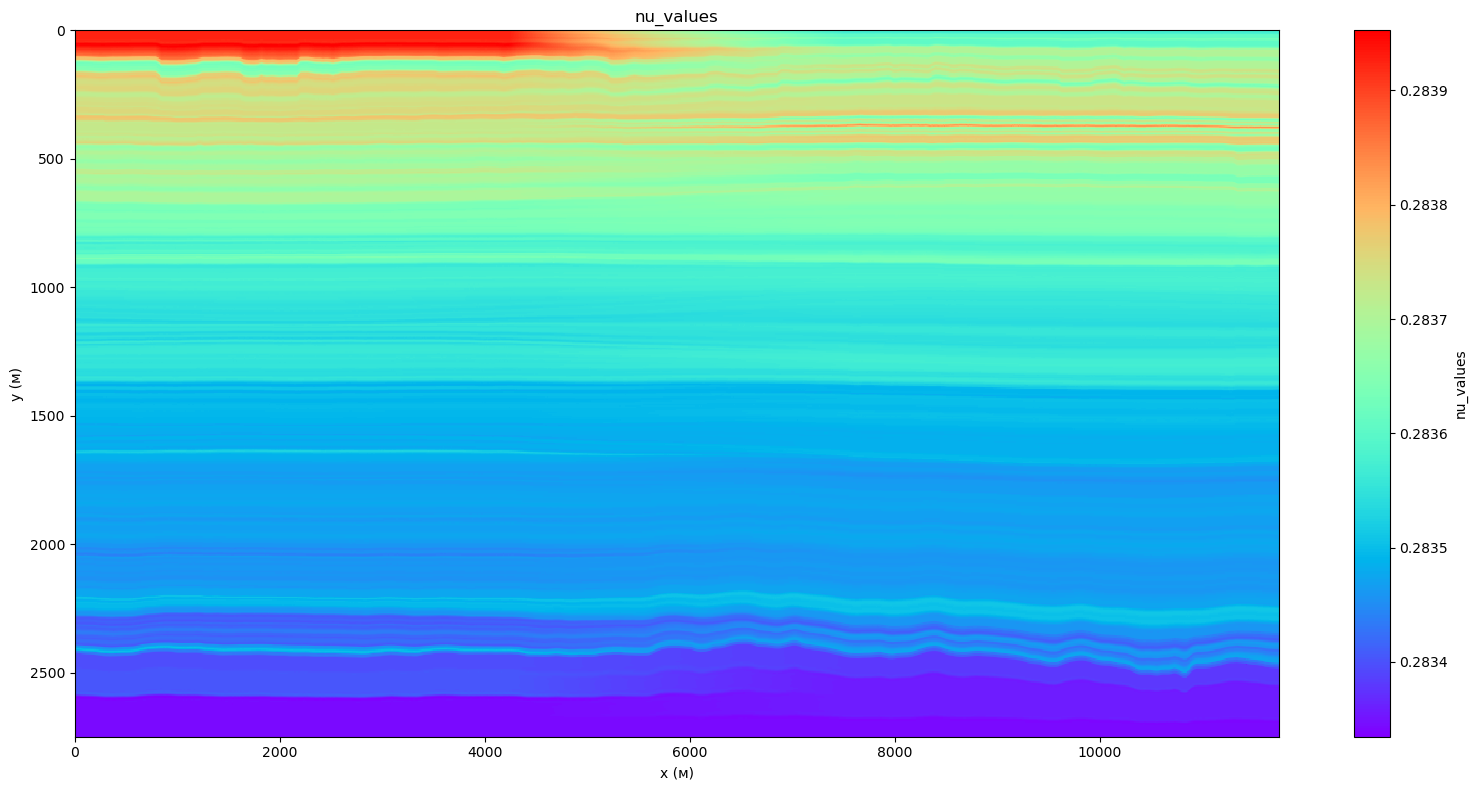

In [70]:
show_plot('nu_values', material_grid[:, :, 1], 'rainbow')

  Визуализация слоев: img/dev_1_7_pho_values_layers.png


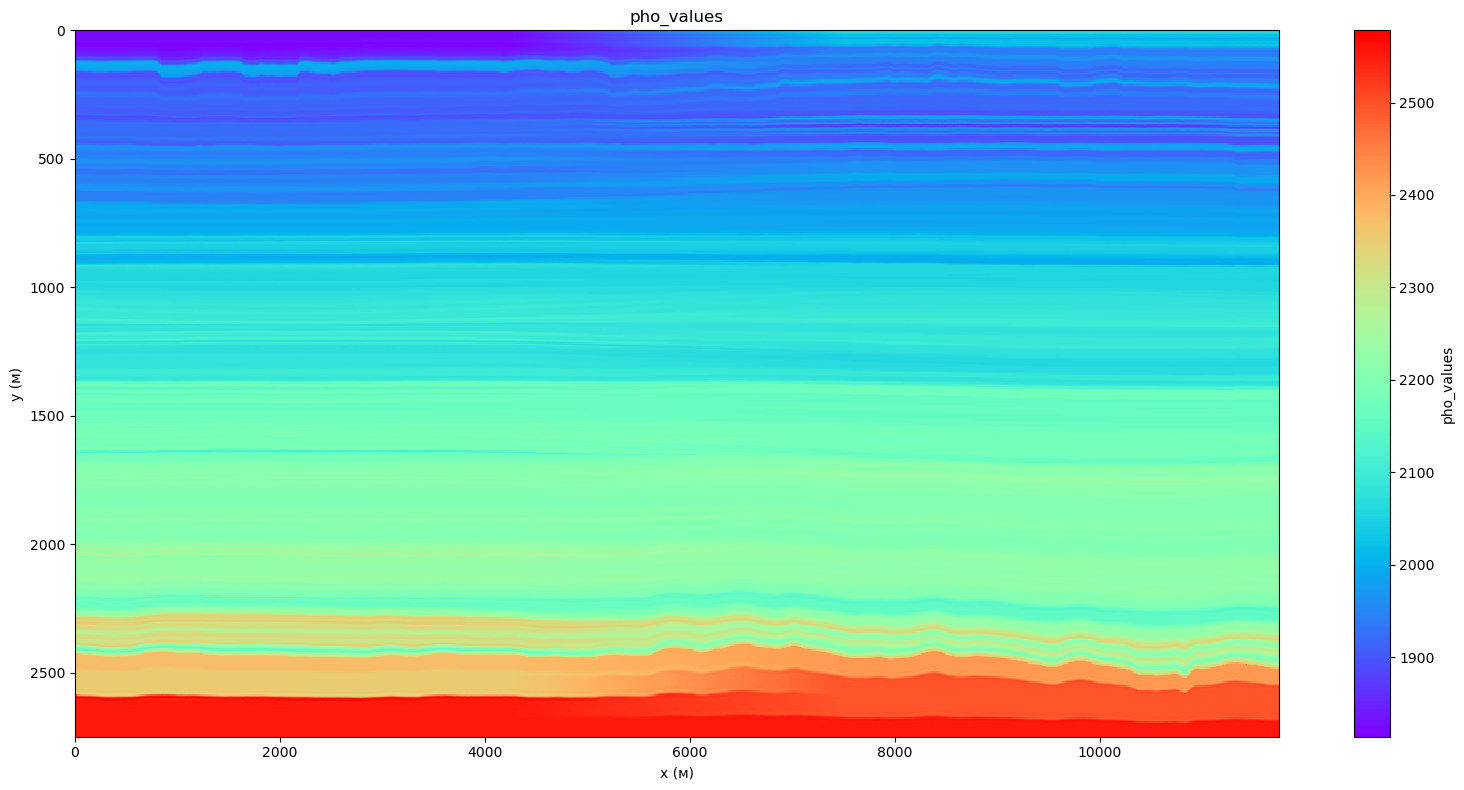

In [71]:
show_plot('pho_values', material_grid[:, :, 2], 'rainbow')

In [72]:
E = material_grid[:, :, 0]
nu = material_grid[:, :, 1]
pho = material_grid[:, :, 2]
Vp = np.sqrt(E/pho * (1-nu)/(1+nu)/(1-2*nu)) 
Vs = np.sqrt(E/pho /2/(1+nu)) 


  Визуализация слоев: img/dev_1_7_Vp_layers.png


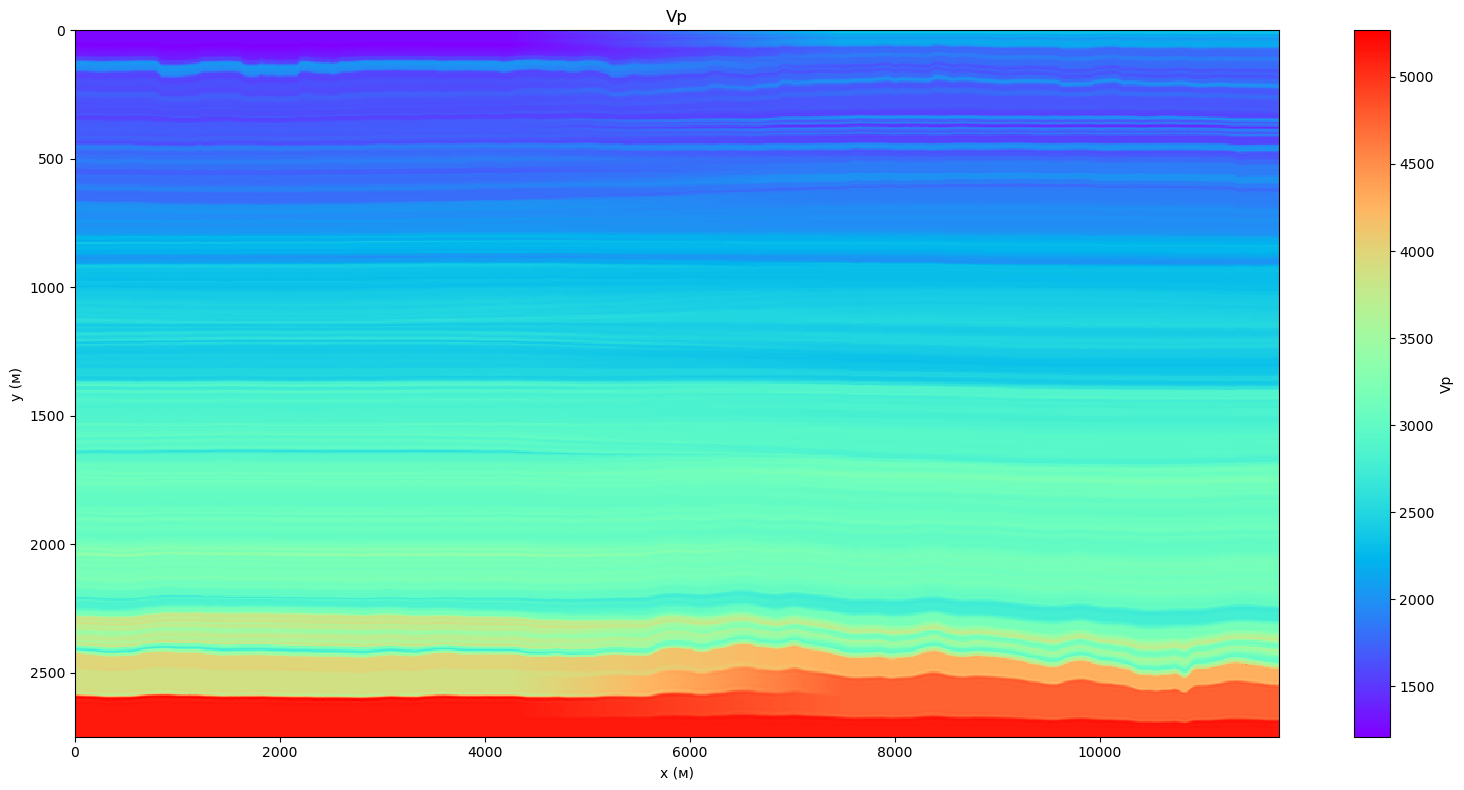

In [73]:
show_plot('Vp', Vp, 'rainbow')

  Визуализация слоев: img/dev_1_7_Vs_layers.png


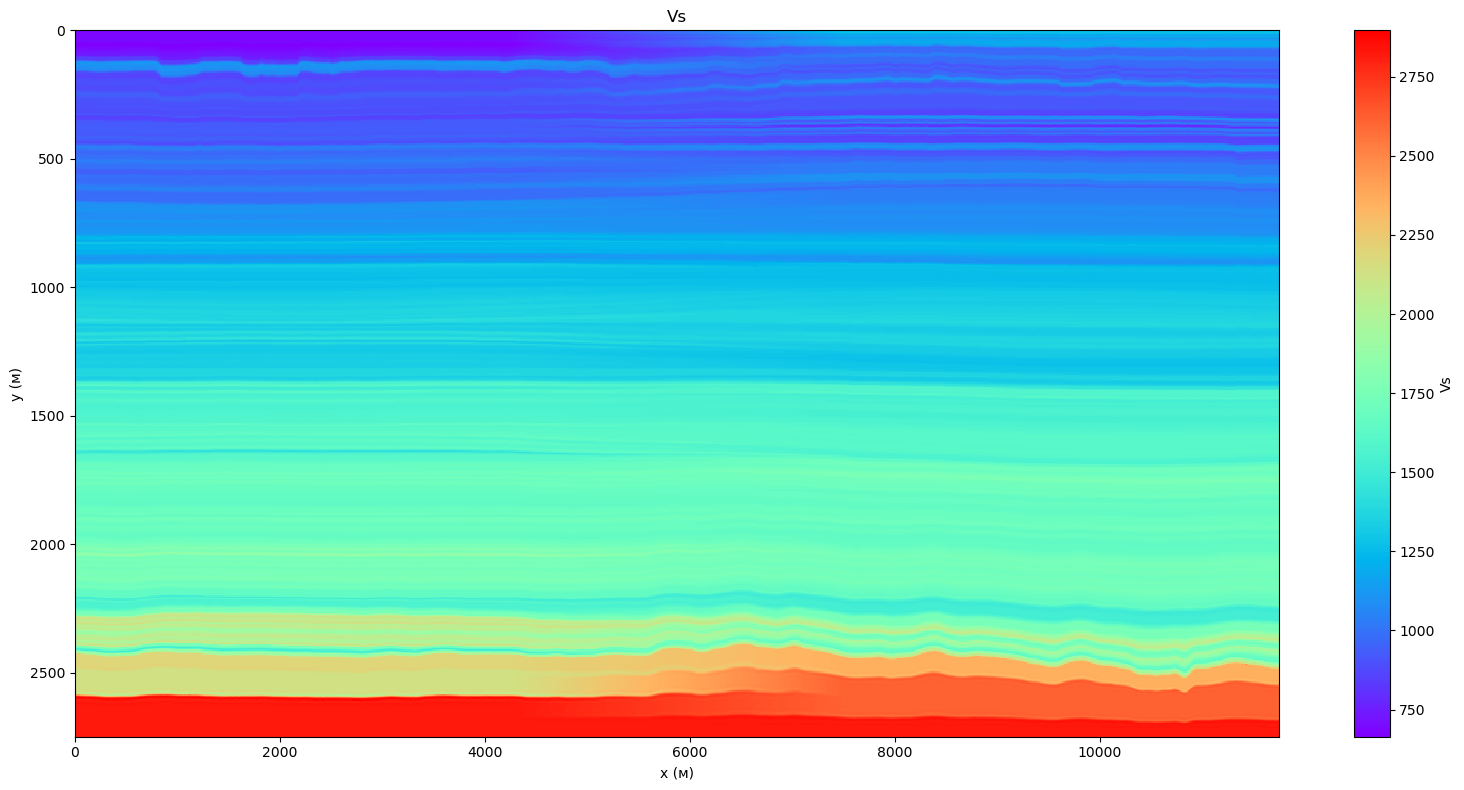

In [74]:
show_plot('Vs', Vs, 'rainbow')

Сохраняем массивы material_grid, coords_grid и layer_indexes_grid на диск

In [75]:
np.savez_compressed('data/dev_1_7_material_grids.npz',
                    material_grid=material_grid,
                    coords_grid=coords_grid,
                    layer_indexes_grid=layer_indexes_grid)
print("Массивы material_grid, coords_grid, layer_indexes_grid сохранены в data/dev_1_7_material_grids.npz")

Массивы material_grid, coords_grid, layer_indexes_grid сохранены в data/dev_1_7_material_grids.npz


#### 5. Построение сетки FDS модели, обновленное ####

Возьмем минимум продольной скорости в слое за меру того, сколь сильно мы можем измельчить слой. Предположим, мы хотим, что бы линейный размер элемента составлял 1/4 длины продольной волны. Это удобно потому, что минимальная толщина слоя - 10 , а в верхней части у нас как раз есть слои тощиной 10, размер элемента которых логично подогнать к 10. По таблице Ухнова для 2D для 5 порядка сетки достаточно 2 элемента (у нас 4) для достижения 1%, так что у нас есть хороший запаc. 

Примечание: таблица Уханова составлялась для пульса Берлаге а не более сложного Рикера, для однородного случая. Поэтому она является оценкой точности *снизу*, минимумом, который нельзя нарушать. Кроме того, иног

In [76]:
el_in_wave = 4
fr = 30
max_len_per_depth = np.min(Vp, axis=(0))/30/el_in_wave
y_depth = np.arange(0, 550*5, 5)

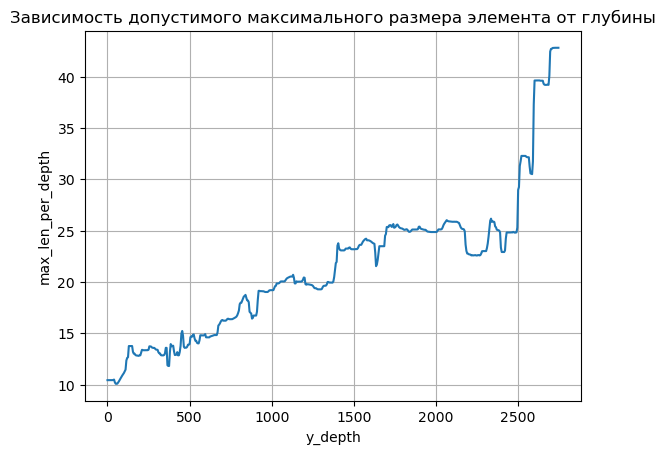

In [77]:
plt.plot(y_depth, max_len_per_depth)
plt.xlabel('y_depth')
plt.ylabel('max_len_per_depth')
plt.title('Зависимость допустимого максимального размера элемента от глубины')
plt.grid(True)
plt.show()

In [78]:
layer_depth = np.mean(layer_boundaries_array, axis=(1))

max_param_per_layer = np.empty(layer_depth.shape[0])
for i, depth in enumerate(layer_depth):
    max_index = int(depth / 5)
    max_param_per_layer[i] = max_len_per_depth[:max_index+1].max()

Делаем первый слой сторого по 10 для удобства расстановки ресиверов

In [79]:
max_param_per_layer[0] = 10


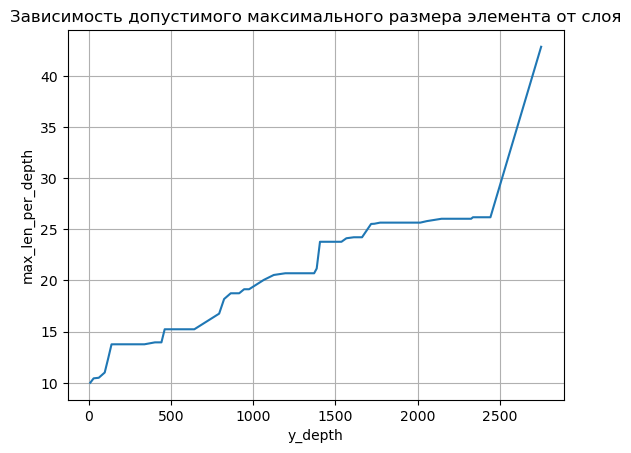

In [80]:
plt.plot(layer_depth, max_param_per_layer)
plt.xlabel('y_depth')
plt.ylabel('max_len_per_depth')
plt.title('Зависимость допустимого максимального размера элемента от слоя')
plt.grid(True)
plt.show()

Главное условие построения сетки схемой pave - четная сумма интервалов на границах. Мы обеспечим это равной четностью в горизонтальных и вертикальных группах. 

Во всех горизонтальных группах число элементов должно быть нечетным.

Горизонтальная длина первой и третей группы - 4250, второй - 3250

Задаем индексы кривых (так они генерируются в fidesys)

In [81]:
h1_line_index = [1, 3] + list(range(12,524,7))
h2_line_index = [5, 7] + list(range(15,527,7))
h3_line_index = [8, 10] + list(range(17,529,7))

v1_line_index = [2] + list(range(13,525,7))
v2_line_index = [4] + list(range(11,523,7))
v3_line_index = [6] + list(range(14,526,7))
v4_line_index = [9] + list(range(16,528,7))


In [82]:
len(h1_line_index)

76

Устанавливаем интервалы по горизонтали (с удобным нулевым слоем)

In [83]:
h1_interval = np.concatenate([[425], np.round(425/max_param_per_layer) * 10 + 5]).astype(int)
h2_interval = np.concatenate([[325], np.round(325/max_param_per_layer) * 10 + 5]).astype(int)
h3_interval = np.concatenate([[425], np.round(425/max_param_per_layer) * 10 + 5]).astype(int)

In [84]:
well1_depths

array([  10,   30,   60,  100,  120,  140,  160,  180,  230,  270,  290,
        320,  340,  400,  430,  440,  460,  490,  530,  550,  590,  630,
        650,  660,  790,  820,  860,  870,  880,  900,  940,  970, 1090,
       1130, 1170, 1220, 1310, 1340, 1360, 1380, 1400, 1410, 1520, 1530,
       1550, 1580, 1600, 1640, 1710, 1730, 1750, 1880, 1910, 1990, 2010,
       2050, 2140, 2170, 2200, 2210, 2230, 2260, 2280, 2300, 2310, 2320,
       2340, 2360, 2370, 2390, 2400, 2410, 2420, 2430, 2460])

In [85]:
well1_layer_height = np.diff(np.concatenate([[0], well1_depths[:-1], [2650]])).astype(int)
well2_layer_height = np.diff(np.concatenate([[0], well2_depths[:-1], [2650]])).astype(int)

In [86]:
well1_layer_height

array([ 10,  20,  30,  40,  20,  20,  20,  20,  50,  40,  20,  30,  20,
        60,  30,  10,  20,  30,  40,  20,  40,  40,  20,  10, 130,  30,
        40,  10,  10,  20,  40,  30, 120,  40,  40,  50,  90,  30,  20,
        20,  20,  10, 110,  10,  20,  30,  20,  40,  70,  20,  20, 130,
        30,  80,  20,  40,  90,  30,  30,  10,  20,  30,  20,  20,  10,
        10,  20,  20,  10,  20,  10,  10,  10,  10, 220])

In [87]:
well2_layer_height

array([ 10,  20,  30,  30,  20,  20,  20,  20,  20,  40,  20,  40,  40,
        70,  30,  10,  20,  30,  20,  30,  30,  20,  20,  10, 170,  30,
        40,  30,  10,  20,  20,  30,  60,  80, 100,  50,  60,  20,  30,
        10,  20,  10, 110,  10,  40,  60,  20,  20,  40,  20,  50, 100,
        30,  80,  20,  40,  90,  30,  30,  10,  50,  40,  10,  10,  10,
        10,  20,  10,  10,  10,  20,  10,  10,  10, 210])

In [88]:


well1_layer_interval = np.ceil(well1_layer_height/max_param_per_layer).astype(int)
well2_layer_interval = np.ceil(well2_layer_height/max_param_per_layer).astype(int)

for i in range(len(well1_layer_interval)):
    parity1 = well1_layer_interval[i] % 2
    parity2 = well2_layer_interval[i] % 2
    if parity1 != parity2:
        if well1_layer_interval[i] > well2_layer_interval[i]:
            well1_layer_interval[i] += 1
        else:
            well2_layer_interval[i] += 1


Это дает представление о неструктурированности слоев:

In [89]:
np.concatenate([
    [well1_layer_interval],
    [well2_layer_interval]
], axis=0).transpose()

array([[ 1,  1],
       [ 2,  2],
       [ 3,  3],
       [ 5,  3],
       [ 2,  2],
       [ 2,  2],
       [ 2,  2],
       [ 2,  2],
       [ 4,  2],
       [ 3,  3],
       [ 2,  2],
       [ 3,  3],
       [ 2,  4],
       [ 5,  7],
       [ 3,  3],
       [ 1,  1],
       [ 2,  2],
       [ 2,  2],
       [ 4,  2],
       [ 2,  2],
       [ 4,  2],
       [ 4,  2],
       [ 2,  2],
       [ 1,  1],
       [ 8, 12],
       [ 2,  2],
       [ 3,  3],
       [ 1,  3],
       [ 1,  1],
       [ 2,  2],
       [ 4,  2],
       [ 2,  2],
       [ 7,  3],
       [ 2,  4],
       [ 2,  6],
       [ 3,  3],
       [ 5,  3],
       [ 3,  1],
       [ 1,  3],
       [ 1,  1],
       [ 1,  1],
       [ 1,  1],
       [ 5,  5],
       [ 1,  1],
       [ 1,  3],
       [ 2,  4],
       [ 1,  1],
       [ 3,  1],
       [ 4,  2],
       [ 1,  1],
       [ 1,  3],
       [ 6,  4],
       [ 2,  2],
       [ 4,  4],
       [ 1,  1],
       [ 2,  2],
       [ 4,  4],
       [ 2,  2],
       [ 2,  2

In [90]:
with open('data/dev_1_7_model_mesh_curve.jou', 'w') as f:
    f.write(f'delete mesh surface all propagate\n')
    f.write(f'delete mesh curve all propagate\n')

    # первая горизональная группа  
    for i, curve_id in enumerate(h1_line_index):
        f.write(f'curve {curve_id} scheme equal interval {h1_interval[i]}\n')

    # вторая горизональная группа  
    for i, curve_id in enumerate(h2_line_index):
        f.write(f'curve {curve_id} scheme equal interval {h2_interval[i]}\n')

    # третья горизональная группа  
    for i, curve_id in enumerate(h3_line_index):
        f.write(f'curve {curve_id} scheme equal interval {h3_interval[i]}\n')

    # первая вертикальная группа
    for i, curve_id in enumerate(v1_line_index):
        f.write(f'curve {curve_id} scheme equal interval {well1_layer_interval[i]}\n')

    # вторая вертикальная группа
    for i, curve_id in enumerate(v2_line_index):
        f.write(f'curve {curve_id} scheme equal interval {well1_layer_interval[i]}\n')

    # третья вертикальная группа
    for i, curve_id in enumerate(v3_line_index):
        f.write(f'curve {curve_id} scheme equal interval {well2_layer_interval[i]}\n')

    # четвертая вертикальная группа
    for i, curve_id in enumerate(v4_line_index):
        f.write(f'curve {curve_id} scheme equal interval {well2_layer_interval[i]}\n')

    f.write(f'mesh curve all\n')


In [91]:
with open('data/dev_1_7_model_mesh_surface.jou', 'w') as f:
    f.write(f'delete mesh surface all\n')

    for i, surf_id in enumerate(range(1,224,3)):
        if h1_interval[i] == h1_interval[i+1]:
            f.write(f'surface {surf_id} scheme map\n')
        else:
            f.write(f'surface {surf_id} scheme pave\n')
        f.write(f'mesh surface {surf_id}\n')

    for i, surf_id in enumerate(range(2,225,3)):
        if h1_interval[i] == h1_interval[i+1] and well1_layer_height[i] == well2_layer_interval[i]:
            f.write(f'surface {surf_id} scheme map\n')
        else:
            f.write(f'surface {surf_id} scheme pave\n')
        f.write(f'mesh surface {surf_id}\n')

    for i, surf_id in enumerate(range(3,226,3)):
        if h1_interval[i] == h1_interval[i+1]:
            f.write(f'surface {surf_id} scheme map\n')
        else:
            f.write(f'surface {surf_id} scheme pave\n')
        f.write(f'mesh surface {surf_id}\n')



Затем мы генерируем модель fc из исходного fds с заглушками материалов, что бы записать файл автоматически. Мы сгенерируем два файла - основной и содержащий только центральную часть, между скважинами (для отладки)


In [92]:
# Загружаем базовую модель
fc_model_path = 'data/dev_1_7_model_material_center_stub.fc'
print(f"\n{'='*60}")
print(f"Загрузка FC модели: {fc_model_path}")
fc_model = FCModel(fc_model_path)


Загрузка FC модели: data/dev_1_7_model_material_center_stub.fc


In [95]:

for layer_idx, formation in enumerate(formations):
    mat_idx = layer_idx + 1  # Индексация материалов с 1
    
    coords_in_layer = np.argwhere(layer_indexes_grid == layer_idx)

    coords_count = len(coords_in_layer)

    print(f"\nОбновление материала {formation} {mat_idx}")
    
    x_coords = coords_grid[coords_in_layer[:,0], coords_in_layer[:,1], 0]
    y_coords = coords_grid[coords_in_layer[:,0], coords_in_layer[:,1], 1]

    E_data = material_grid[coords_in_layer[:,0], coords_in_layer[:,1], 0]
    nu_data = material_grid[coords_in_layer[:,0], coords_in_layer[:,1], 1]
    pho_data = material_grid[coords_in_layer[:,0], coords_in_layer[:,1], 2]

    # Обновляем модуль Юнга (MODULUS)
    fc_model.materials[mat_idx].properties['elasticity'][0][0].data.table[0].value.data = x_coords
    fc_model.materials[mat_idx].properties['elasticity'][0][0].data.table[1].value.data = y_coords
    fc_model.materials[mat_idx].properties['elasticity'][0][0].data.value.data = E_data
    
    # Обновляем коэффициент Пуассона (POISSON)
    fc_model.materials[mat_idx].properties['elasticity'][0][1].data.table[0].value.data = x_coords
    fc_model.materials[mat_idx].properties['elasticity'][0][1].data.table[1].value.data = y_coords
    fc_model.materials[mat_idx].properties['elasticity'][0][1].data.value.data = nu_data
    
    # Обновляем плотность (DENSITY)
    fc_model.materials[mat_idx].properties['common'][0][0].data.table[0].value.data = x_coords
    fc_model.materials[mat_idx].properties['common'][0][0].data.table[1].value.data = y_coords
    fc_model.materials[mat_idx].properties['common'][0][0].data.value.data = pho_data
    
    # Создаем массив демпфирования
    mass_matrix_damping = np.zeros(coords_count)
    
    for j in range(coords_count):
        x = x_coords[j]
        y = y_coords[j]
        
        # Применяем демпфирование на краях модели
        if x < 150 or x > 11600 or y > 2500:
            damping_x = 0
            damping_y = 0
            
            if x < 250:
                damping_x = 100 * ((150 - x) / 150) ** 2
            elif x > 11600:
                damping_x = 100 * ((x - 11600) / 150) ** 2
            
            if y > 2500:
                damping_y = 100 * ((y - 2400) / 150) ** 2
            
            mass_matrix_damping[j] = max(damping_x, damping_y)
    
    # Обновляем демпфирование (MASS_MATRIX_DAMPING)
    fc_model.materials[mat_idx].properties['common'][0][1].data.table[0].value.data = x_coords
    fc_model.materials[mat_idx].properties['common'][0][1].data.table[1].value.data = y_coords
    fc_model.materials[mat_idx].properties['common'][0][1].data.value.data = mass_matrix_damping
    
    print(f"  Обновлено {coords_count} узлов материала")




Обновление материала песчаник 1
  Обновлено 4700 узлов материала

Обновление материала песчаник 2
  Обновлено 10079 узлов материала

Обновление материала песчаник 3
  Обновлено 14401 узлов материала

Обновление материала песчаник 4
  Обновлено 17006 узлов материала

Обновление материала песчаник 5
  Обновлено 9825 узлов материала

Обновление материала песчаник 6
  Обновлено 9645 узлов материала

Обновление материала песчаник 7
  Обновлено 9728 узлов материала

Обновление материала песчаник 8
  Обновлено 9733 узлов материала

Обновление материала песчаник 9
  Обновлено 16517 узлов материала

Обновление материала глина 10
  Обновлено 18523 узлов материала

Обновление материала глина 11
  Обновлено 9437 узлов материала

Обновление материала глина 12
  Обновлено 16148 узлов материала

Обновление материала глина 13
  Обновлено 13923 узлов материала

Обновление материала песчаник 14
  Обновлено 29759 узлов материала

Обновление материала песчаник 15
  Обновлено 13988 узлов материала

Обновл

#### 6. Сохранение результатов ####

In [96]:
# Сохраняем обновленную модель
output_fc_path = 'data/dev_1_7_model_material_cartes_center.fc'
fc_model.save(output_fc_path)
print(f"\n{'='*60}")
print(f"FC модель сохранена: {output_fc_path}")
print('='*60)


FC модель сохранена: data/dev_1_7_model_material_cartes_center.fc
